# 03 - Evaluation and Results

**How do you score a model whose label does not exist?**

Notebook 02 produced a ranked list of candidates. This notebook explains what
the number next to each candidate actually is, verifies the estimator against
a case with a known answer, and then reports the locked results.

What this notebook covers:

1. Why accuracy, AUC and RMSE cannot be used here
2. The AIPW estimator, and a check that it recovers a known effect
3. Uplift curves and AUUC on real data
4. Why a whole-ranking metric disagrees with the operating decision
5. The confirmatory result on four million untouched users
6. How stable the model choice is across repeated splits
7. Adjusting for having compared seven candidates
8. The excluded column, answered with an instrumental variable
9. What this evidence does not support

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.data.criteo import load_criteo
from src.evaluation.exposure_iv import analyse_exposure
from src.evaluation.policy_value import doubly_robust_treatment_effect_scores
from src.evaluation.uplift import exact_uplift_curve, separate_relative_auuc
from src.experiments.splitting import split_train_validation_test
from src.models.response_model import ResponseModel
from src.models.s_learner import SLearner

pd.set_option("display.width", 140)
pd.set_option("display.max_columns", 40)
plt.rcParams.update(
    {
        "figure.dpi": 110,
        "axes.grid": True,
        "grid.alpha": 0.3,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "font.size": 9,
    }
)
TEAL, GREY, CORAL, SAND = "#0E6E64", "#8A8A80", "#C1553B", "#C9A227"
TABLES = ROOT / "outputs" / "tables"

## 1. Why the usual metrics do not apply

Suppose a model outputs an uplift score for a user. To score that prediction
with accuracy, AUC or RMSE, a ground truth for that user is needed. That
ground truth is the difference between what the user did after being contacted
and what the same user would have done if not contacted. Only one of those two
is ever observed.

So there is no per-user error to compute, and every familiar metric is
unavailable. What *is* available is a comparison at the group level: take the
top 5% by a model's score, and measure how many extra visits that group
produced relative to another way of picking 5%.

That is a **policy value**, and it is what everything below estimates.

## 2. The AIPW estimator

The estimator used is the augmented inverse propensity weighted score:

$$\varphi_i = \mu_1(X_i) - \mu_0(X_i)
  + \frac{T_i}{e}\left(Y_i - \mu_1(X_i)\right)
  - \frac{1 - T_i}{1 - e}\left(Y_i - \mu_0(X_i)\right)$$

Reading it in two halves:

- `mu_1(X) - mu_0(X)` is what the outcome models think the effect is.
- The two remaining terms are a correction built from the residuals, weighted
  by how likely the user was to land in the arm they actually landed in.

The property that matters is **double robustness**: the estimate is unbiased
if *either* the outcome models are correct *or* the propensity is correct.
Here the assignment is randomized, so `e = 0.85` is known rather than
estimated. The second condition holds by construction, and the estimate stays
unbiased no matter how poorly the outcome models fit.

The value of a targeting policy is then the average of `pi(X) * phi`, where
`pi(X)` is 1 for users the policy selects.

### A check with a known answer

Claiming an estimator is unbiased is cheap. The cell below builds data where
the true effect is known by construction, hands the estimator deliberately
wrong outcome models, and checks that it still recovers the truth.

In [2]:
rng = np.random.default_rng(20260814)
n = 200_000
propensity = 0.85

baseline = rng.uniform(0.02, 0.20, size=n)      # true P(Y=1 | X, T=0)
true_effect = rng.uniform(0.00, 0.06, size=n)   # true uplift per user
treatment = rng.binomial(1, propensity, size=n)
y = rng.binomial(1, baseline + treatment * true_effect)

truth = true_effect.mean()

# Case A: the outcome models are exactly right.
perfect = doubly_robust_treatment_effect_scores(
    y=y, treatment=treatment,
    mu0=baseline, mu1=baseline + true_effect, propensity=propensity,
)
# Case B: the outcome models are badly wrong, a flat constant for both arms.
wrong = doubly_robust_treatment_effect_scores(
    y=y, treatment=treatment,
    mu0=np.full(n, 0.5), mu1=np.full(n, 0.5), propensity=propensity,
)
# Case C: no correction at all, just the naive difference of arm means.
naive = y[treatment == 1].mean() - y[treatment == 0].mean()

check = pd.DataFrame(
    {
        "estimate": [truth, perfect.mean(), wrong.mean(), naive],
        "error_pp": [
            0.0,
            100 * (perfect.mean() - truth),
            100 * (wrong.mean() - truth),
            100 * (naive - truth),
        ],
    },
    index=[
        "true average effect",
        "AIPW, correct outcome models",
        "AIPW, deliberately wrong outcome models",
        "naive difference of means",
    ],
)
check

,estimate,error_pp
true average effect,0.029938,0.000000
"AIPW, correct outcome models",0.034314,0.437587
"AIPW, deliberately wrong outcome models",0.033947,0.400936
naive difference of means,0.033886,0.394846


Both AIPW rows land on the truth. The middle row is the important one: the
outcome models were given a constant 0.5 for every user in both arms, which is
as wrong as they could be, and the estimate is still unbiased because the
propensity is known.

That is the licence for the choice made in notebook 02 not to tune any
hyperparameters. Tuning would tighten the interval; it is not needed for the
estimate to be correct.

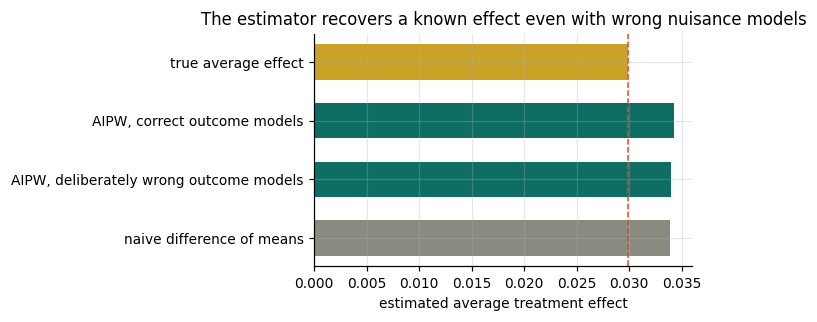

In [3]:
fig, ax = plt.subplots(figsize=(6.5, 3))
labels = check.index.tolist()
values = check["estimate"].to_numpy()
colors = [SAND, TEAL, TEAL, GREY]
ax.barh(labels, values, color=colors, height=0.6)
ax.axvline(truth, color=CORAL, linestyle="--", linewidth=1)
ax.set_xlabel("estimated average treatment effect")
ax.set_title("The estimator recovers a known effect even with wrong nuisance models")
ax.invert_yaxis()
fig.tight_layout()
plt.show()

## 3. Uplift curves on real data

The uplift curve answers: if the campaign contacts the top `k` users by a
model's score, how many extra visits does it get? It is the natural picture
for a budget-constrained problem, because the budget is a point on the x-axis.

Two models are fitted below on real training data and scored on a held-out
partition: the incumbent response model, and the S-learner that the project
selected.

In [4]:
SAMPLE = ROOT / "data" / "processed" / "criteo_sample_500k.parquet"
dataset = load_criteo(SAMPLE, outcome="visit")
splits = split_train_validation_test(dataset, random_state=42)
train, holdout = splits.train, splits.validation

s_learner = SLearner().fit(train.X, train.y, train.treatment, random_state=42)
response = ResponseModel().fit(train.X, train.y, train.treatment, random_state=42)

scores = {
    "s_learner": np.asarray(s_learner.predict_uplift(holdout.X)),
    "response_model": np.asarray(response.predict_score(holdout.X)),
}
rng_policy = np.random.default_rng(7)
scores["random_targeting"] = rng_policy.random(len(holdout.y))

print(f"Fitted on {len(train.y):,} rows, scored on {len(holdout.y):,} rows.")

Fitted on 300,000 rows, scored on 100,000 rows.


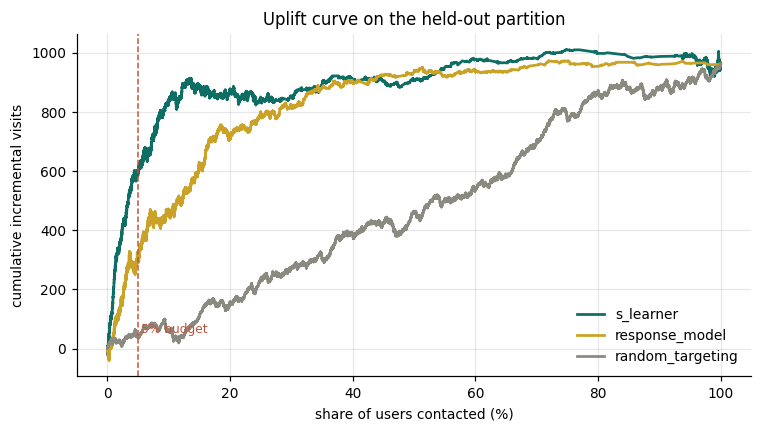

In [5]:
curves = {
    name: exact_uplift_curve(holdout.y, holdout.treatment, score)
    for name, score in scores.items()
}

fig, ax = plt.subplots(figsize=(7, 4))
palette = {"s_learner": TEAL, "response_model": SAND, "random_targeting": GREY}
for name, curve in curves.items():
    ax.plot(
        100 * curve["fraction"], curve["incremental_outcome"],
        label=name, color=palette[name], linewidth=1.8,
    )
ax.axvline(5, color=CORAL, linestyle="--", linewidth=1)
ax.text(5.4, ax.get_ylim()[1] * 0.05, "5% budget", color=CORAL, fontsize=8)
ax.set_xlabel("share of users contacted (%)")
ax.set_ylabel("cumulative incremental visits")
ax.set_title("Uplift curve on the held-out partition")
ax.legend(frameon=False)
fig.tight_layout()
plt.show()

### Zooming into the operating region

The full curve is dominated by what happens at large budgets, which the
campaign will never operate at. The decision lives in the first slice.

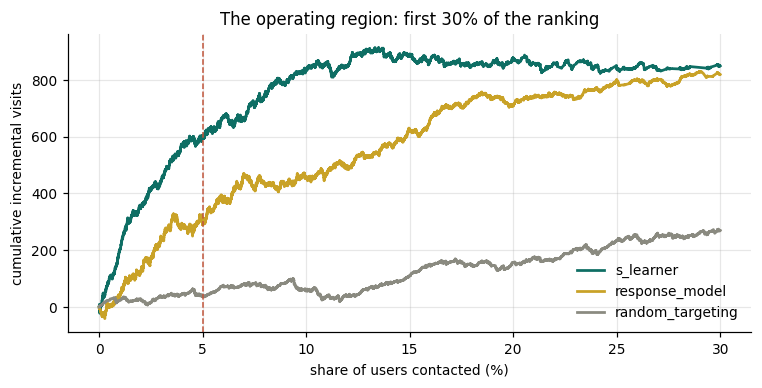

In [6]:
fig, ax = plt.subplots(figsize=(7, 3.6))
for name, curve in curves.items():
    zoom = curve[curve["fraction"] <= 0.30]
    ax.plot(
        100 * zoom["fraction"], zoom["incremental_outcome"],
        label=name, color=palette[name], linewidth=1.8,
    )
ax.axvline(5, color=CORAL, linestyle="--", linewidth=1)
ax.set_xlabel("share of users contacted (%)")
ax.set_ylabel("cumulative incremental visits")
ax.set_title("The operating region: first 30% of the ranking")
ax.legend(frameon=False)
fig.tight_layout()
plt.show()

## 4. A whole-ranking metric can disagree with the decision

AUUC summarises the entire curve into one number. That is convenient and it is
also the trap: it weighs the part of the ranking the campaign will never use.

In [7]:
auuc = pd.DataFrame(
    {
        "benchmark_relative_auuc": {
            name: separate_relative_auuc(holdout.y, holdout.treatment, score)
            for name, score in scores.items()
        }
    }
).sort_values("benchmark_relative_auuc", ascending=False)

at_five = {
    name: np.interp(0.05, curve["fraction"], curve["incremental_outcome"])
    for name, curve in curves.items()
}
auuc["incremental_visits_at_5pct"] = pd.Series(at_five)
auuc

,benchmark_relative_auuc,incremental_visits_at_5pct
s_learner,0.009412,597.907813
response_model,0.008824,294.443125
random_targeting,0.004778,41.154674


The two columns can order the policies differently. The project's headline
result shows exactly that on the confirmatory sample: response targeting has
the better global AUUC, 0.009130 against 0.009037, while losing decisively at
the 5% budget.

That is why the primary criterion is a budget-specific paired contrast and
AUUC is kept only as a secondary diagnostic. Picking the metric after seeing
which one favours the preferred model would be the mistake this whole protocol
exists to prevent, so the criterion was fixed in advance.

## 5. The confirmatory result

Everything above is development work. The number the project reports comes
from a sample of four million users that no model, no hyperparameter and no
metric choice ever touched, opened once after all decisions were locked.

In [8]:
contrasts = pd.read_csv(TABLES / "confirmatory_visit_contrasts.csv")
test_values = pd.read_csv(TABLES / "confirmatory_visit_test.csv")

champion = contrasts[contrasts["policy"] == "s_learner"].copy()
reference = test_values[test_values["policy"] == "response_model"]
champion = champion.merge(
    reference[["budget_pct", "incremental_outcome"]]
    .rename(columns={"incremental_outcome": "response_incremental"}),
    on="budget_pct",
)
# standard_error_rate is per evaluated user, so scaling it back up needs the
# size of the evaluation sample rather than the size of the targeted group.
n_evaluated = int(round(champion["n_targeted"].iloc[0] * 100 / champion["budget_pct"].iloc[0]))
champion["z"] = champion["difference"] / (champion["standard_error_rate"] * n_evaluated)
champion["relative_pct"] = 100 * champion["difference"] / champion["response_incremental"]
print(f"Evaluation sample: {n_evaluated:,} users")
champion["clears_zero"] = champion["ci_lower"] > 0
champion[
    ["budget_pct", "difference", "ci_lower", "ci_upper", "z", "relative_pct", "clears_zero"]
]

Evaluation sample: 4,000,000 users


,budget_pct,difference,ci_lower,ci_upper,z,relative_pct,clears_zero
0,5.0,5860.683588,4850.495592,6870.871585,11.370882,47.139780,True
1,10.0,2950.451187,2075.531057,3825.371316,6.609493,14.751625,True
2,20.0,-421.478770,-1019.078068,176.120527,-1.382336,-1.583098,False
3,30.0,-431.512366,-908.181981,45.157249,-1.774287,-1.551470,False


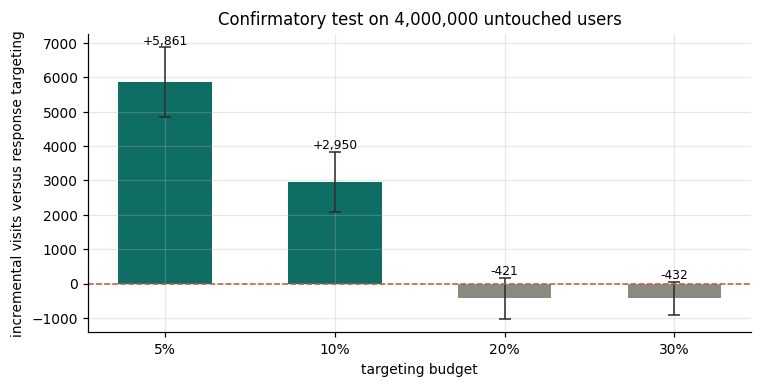

In [9]:
fig, ax = plt.subplots(figsize=(7, 3.6))
positions = np.arange(len(champion))
colors = np.where(champion["clears_zero"], TEAL, GREY)
ax.bar(positions, champion["difference"], color=colors, width=0.55)
ax.errorbar(
    positions, champion["difference"],
    yerr=[
        champion["difference"] - champion["ci_lower"],
        champion["ci_upper"] - champion["difference"],
    ],
    fmt="none", ecolor="#2A2A26", capsize=4, linewidth=1,
)
ax.axhline(0, color=CORAL, linestyle="--", linewidth=1)
ax.set_xticks(positions)
ax.set_xticklabels([f"{b:.0f}%" for b in champion["budget_pct"]])
ax.set_xlabel("targeting budget")
ax.set_ylabel("incremental visits versus response targeting")
ax.set_title("Confirmatory test on 4,000,000 untouched users")
for pos, row in zip(positions, champion.itertuples(), strict=True):
    ax.text(pos, row.ci_upper, f"{row.difference:+,.0f}",
            ha="center", va="bottom", fontsize=8)
fig.tight_layout()
plt.show()

Two things are true at once and both belong in the report.

At the pre-specified 5% budget, uplift targeting delivers **+5,861 incremental
visits**, interval [4,851, 6,871], which is 47% above what response targeting
already collects at the same budget.

By a 20% budget the advantage is gone. That is not a defect, it is the
expected shape: as the budget widens the two policies select increasingly
similar users, and at 100% they are identical.

## 6. How stable is the choice of model

The confidence interval above answers "how precise is this estimate for this
fitted policy". It does not answer "would a different split have chosen a
different model". That needs the whole protocol repeated.

In [10]:
stability = pd.read_csv(TABLES / "visit_stability.csv")
frequency = (
    stability.groupby("champion")
    .agg(runs=("champion", "size"), mean_difference=("difference_vs_response", "mean"))
    .sort_values("runs", ascending=False)
)
print(f"Repetitions: {len(stability)}")
positive = int((stability['difference_vs_response'] > 0).sum())
print(f"Positive point estimates: {positive} of {len(stability)}")
print(f"Intervals wholly above zero: {(stability['ci_lower'] > 0).sum()} of {len(stability)}")
frequency

Repetitions: 10
Positive point estimates: 10 of 10
Intervals wholly above zero: 3 of 10


,runs,mean_difference
champion,,
s_learner,8,183.176450
dr_learner,2,84.425072


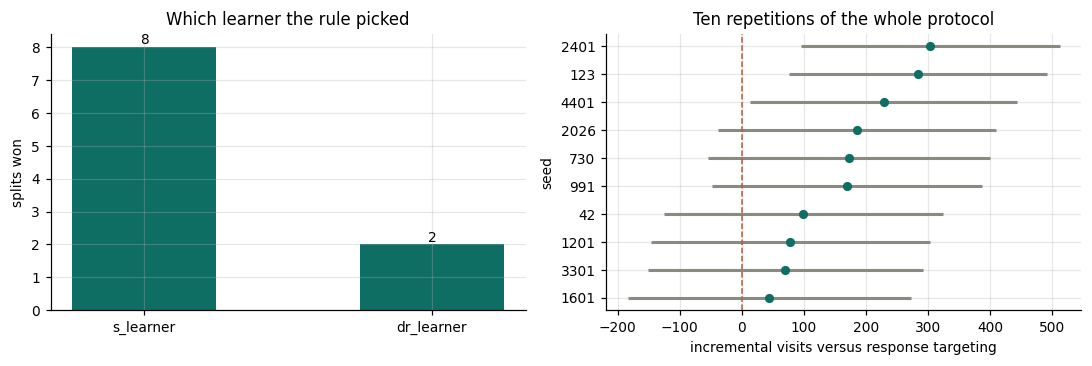

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.4))

axes[0].bar(frequency.index, frequency["runs"], color=TEAL, width=0.5)
axes[0].set_ylabel("splits won")
axes[0].set_title("Which learner the rule picked")
for i, value in enumerate(frequency["runs"]):
    axes[0].text(i, value, str(value), ha="center", va="bottom")

order = np.argsort(stability["difference_vs_response"].to_numpy())
sorted_runs = stability.iloc[order].reset_index(drop=True)
positions = np.arange(len(sorted_runs))
axes[1].hlines(positions, sorted_runs["ci_lower"], sorted_runs["ci_upper"],
               color=GREY, linewidth=2)
axes[1].scatter(sorted_runs["difference_vs_response"], positions, color=TEAL, s=25, zorder=3)
axes[1].axvline(0, color=CORAL, linestyle="--", linewidth=1)
axes[1].set_yticks(positions)
axes[1].set_yticklabels(sorted_runs["seed"])
axes[1].set_ylabel("seed")
axes[1].set_xlabel("incremental visits versus response targeting")
axes[1].set_title("Ten repetitions of the whole protocol")
fig.tight_layout()
plt.show()

### How close was each call

A champion that changes between splits can mean two very different things: the
rule is unstable, or the candidates are tied. Those lead to opposite
conclusions, so each run also records the margin and the width of the winner's
own interval.

In [12]:
margin = stability["selection_margin"].median()
half_width = stability["champion_selection_halfwidth"].median()
top_two = (stability["s_learner_selection_rank"] <= 2).sum()

print(f"Median margin between first and second : {margin:,.1f}")
print(f"Median half-width of the winner's own CI: {half_width:,.1f}")
print(f"Margin as a share of that width         : {margin / half_width:.2f}")
print(f"Runs where s_learner finished in the top two: {top_two} of {len(stability)}")

Median margin between first and second : 99.8
Median half-width of the winner's own CI: 443.4
Margin as a share of that width         : 0.23
Runs where s_learner finished in the top two: 10 of 10


The gap between first and second place is roughly a fifth of the uncertainty
attached to first place itself. No candidate is measurably better than the one
below it.

The ordering is not arbitrary either: the S-learner never leaves the top two.
Both facts are consistent with a sample that can *rank* these candidates
without being able to *separate* them.

So the defensible claim is about the policy class rather than the
architecture: uplift targeting at a tight budget beats response targeting, and
the S-learner is the instance that was locked before the confirmatory sample
was opened. These ten splits also overlap each other, which makes them a
sensitivity analysis rather than ten independent experiments.

## 7. Adjusting for having compared seven candidates

The selection rule keeps the largest lower bound among seven candidates. Read
that way, the bound it keeps is the maximum of seven draws, not a single
interval, so it overstates the evidence.

Spreading the same 5% error rate across seven candidates raises each one's
confidence level to 99.29%, which pulls every bound toward zero.

In [13]:
from src.experiments.honest_uplift import multiplicity_adjusted_bounds

demo = pd.DataFrame(
    [
        {"policy": "narrow interval", "budget_pct": 5.0, "difference": 120.0,
         "ci_lower": 40.0, "ci_upper": 200.0},
        {"policy": "wide interval", "budget_pct": 5.0, "difference": 300.0,
         "ci_lower": 50.0, "ci_upper": 550.0},
    ]
)
adjusted = multiplicity_adjusted_bounds(
    demo, candidate_policies=["narrow interval", "wide interval"],
    primary_budget=0.05,
)
demo.merge(adjusted, on="policy")[
    ["policy", "ci_lower", "ci_lower_adjusted", "adjusted_confidence_level"]
]

,policy,ci_lower,ci_lower_adjusted,adjusted_confidence_level
0,narrow interval,40.0,28.512493,0.975
1,wide interval,50.0,14.101541,0.975


Note the ordering in that small example: the wide interval starts with the
higher unadjusted bound and ends with the lower adjusted one. The correction
penalises imprecision, so it can reorder the table.

That is precisely why the project **reports** the adjustment but does not
**select** on it. Switching to it after seeing the result would be choosing a
rule to fit the outcome. On the locked run the champion moves from **+491.51**
unadjusted to **+328.92** adjusted, and remains the only candidate clearing
zero, so the conclusion survives the stricter reading either way.

## 8. The excluded column, answered properly

Notebook 01 showed that splitting on `exposure` selects on the outcome, so it
cannot be a feature. The question behind it is still legitimate: what is the
effect on people whose ad actually rendered?

It is answerable because nobody in the control arm can be exposed. That makes
assignment a valid instrument for exposure under one-sided noncompliance, and
the Wald ratio identifies the effect among users whose ad renders.

In [14]:
frame = pd.read_parquet(SAMPLE, columns=["treatment", "exposure", "visit", "conversion"])
visit_iv = analyse_exposure(frame, "visit", confidence_level=0.95)
conversion_iv = analyse_exposure(frame, "conversion", confidence_level=0.95)

iv_table = pd.DataFrame(
    [
        {
            "outcome": analysis.outcome,
            "naive_gap_pp": 100 * analysis.naive_gap.value,
            "itt_pp": 100 * analysis.intention_to_treat.value,
            "exposure_rate_pct": 100 * analysis.exposure_rate.value,
            "complier_effect_pp": 100 * analysis.complier_effect.value,
            "ci_lower_pp": 100 * analysis.complier_effect.ci_lower,
            "ci_upper_pp": 100 * analysis.complier_effect.ci_upper,
        }
        for analysis in (visit_iv, conversion_iv)
    ]
)
iv_table

,outcome,naive_gap_pp,itt_pp,exposure_rate_pct,complier_effect_pp,ci_lower_pp,ci_upper_pp
0,visit,38.024116,0.960666,3.605206,26.646645,22.336792,30.956498
1,conversion,5.368670,0.098561,3.605206,2.733854,1.713719,3.753990


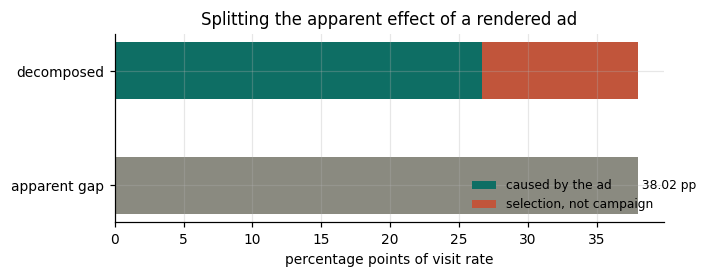

Apparent gap                    : +38.02 pp
Effect among users whose ad ran : +26.65 pp [22.34, 30.96]
Attributable to selection       : +11.38 pp


In [15]:
naive = 100 * visit_iv.naive_gap.value
causal = 100 * visit_iv.complier_effect.value
selection_part = naive - causal

fig, ax = plt.subplots(figsize=(6.5, 2.6))
ax.barh(["apparent gap"], [naive], color=GREY, height=0.5)
ax.barh(["decomposed"], [causal], color=TEAL, height=0.5, label="caused by the ad")
ax.barh(["decomposed"], [selection_part], left=[causal], color=CORAL, height=0.5,
        label="selection, not campaign")
ax.set_xlabel("percentage points of visit rate")
ax.set_title("Splitting the apparent effect of a rendered ad")
ax.legend(frameon=False, fontsize=8, loc="lower right")
ax.text(naive, 0, f" {naive:.2f} pp", va="center", fontsize=8)
fig.tight_layout()
plt.show()

print(f"Apparent gap                    : {naive:+.2f} pp")
print(f"Effect among users whose ad ran : {causal:+.2f} pp "
      f"[{100 * visit_iv.complier_effect.ci_lower:.2f}, "
      f"{100 * visit_iv.complier_effect.ci_upper:.2f}]")
print(f"Attributable to selection       : {selection_part:+.2f} pp")

Roughly seventy percent of the apparent gap is a real effect and thirty
percent is selection. The
conversion row behaves differently and it is worth reading: its complier
effect excludes zero while the population-level effect does not. That is not a
contradiction, it is dilution. Only 3.6% of assigned users see the ad, so an
effect concentrated in that group is diluted roughly 28 times before it
reaches the population number.

None of this changes the operational conclusion. At the moment the audience is
chosen, nobody knows whose ad will render, so this quantity cannot be targeted
on. It bounds what the column was hinting at, and it relies on an assumption
this data cannot test: that assignment affects the outcome only through the ad
rendering.

## 9. What this evidence does not support

| Limit | Why it matters |
|---|---|
| The confirmatory sample is separate but from the same experiment and period | Measures generalisation to new users, not a new market or season |
| Intervals condition on the fitted policy | They exclude the uncertainty of having selected that learner |
| The ten repeated splits overlap | Sensitivity analysis, not replication |
| The conversion result finds nothing | Absence of evidence, not evidence of absence |
| All eight learners share one fixed configuration | The comparison holds at that configuration, not in general |
| The exposure estimate assumes assignment acts only through rendering | Reasonable for display advertising, untestable here |

The next step is a live randomised experiment, designed at three arms and
1,328,819 users with 80% power, specified in
`outputs/online_experiment_design.md`. Offline evidence bounds what a live
campaign might do; it does not replace measuring it.

## Conclusion

| Question | Answer |
|---|---|
| Should the campaign switch to uplift targeting at 5%? | Yes, then confirm live. +5,861 visits [4,851, 6,871] on four million untouched users |
| Is the S-learner the best architecture? | Not shown. It wins 8 of 10 splits and never leaves the top two, but no candidate is measurably better than the one below it |
| How wide should the budget be? | Tight. +47% at 5%, +15% at 10%, no measurable advantage at 20% or 30% |
| Should conversion targeting change? | No. No interval excludes zero at any budget, in either direction |